### *Machine Learning with project predict house price with numpy*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# samples with X and y
X = np.array([30, 40, 50, 60, 70, 80, 90, 100]) # square of house (m^2)
y = np.array([1.2, 1.6, 2.1, 2.4, 2.9, 3.2, 3.8, 4.1]) # price of house (bilion VND)

In [3]:
# init random parameters
w = 0.0
b = 0.0

In [4]:
# set hyperparameters
learning_rate = 1e-4
epochs = 5

### *LOSS FUNCTION - MSE*
$$Loss = \frac{1}{n} \sum (y_{pred} - y_{real})^2$$

In [5]:
def compute_loss(X, y, w, b):
    n = len(X)
    y_pred =  w * X + b
    return (np.sum((y - y_pred)**2)) / n

### *Gradient Descent - Model learning with speed is learning rate*

In [6]:
# how to find min of LOSS??
# Use deriviative to solve it! deriviative of LOSS!
def update_weights(X, y, w, b, learning_rate):
    n = len(X)
    y_pred = w*X + b

    dw = 2*(np.sum(X*(y_pred - y))) / n
    db = 2*(np.sum(y_pred - y)) / n

    w = w - learning_rate*dw
    b = b - learning_rate*db

    return w, b

In [7]:
print("Training!")

loss_history = []

for i in range(epochs):
    w, b = update_weights(X, y, w, b, learning_rate)
    current_loss = compute_loss(X, y, w, b)
    loss_history.append(current_loss)
    print(f"Epoch {i+1}: w={w:.4f}, b={b:.4f}, loss={current_loss:.4f}")

print('-' * 10)
print(f"Final result: Price = {w:.4f} * Square + {b:.4f}")

Training!
Epoch 1: w=0.0390, b=0.0005, loss=0.0234
Epoch 2: w=0.0409, b=0.0006, loss=0.0035
Epoch 3: w=0.0410, b=0.0006, loss=0.0035
Epoch 4: w=0.0410, b=0.0006, loss=0.0035
Epoch 5: w=0.0410, b=0.0006, loss=0.0035
----------
Final result: Price = 0.0410 * Square + 0.0006


In [8]:
print("--- Predict house prices ---")

def predict_price(square, w, b):
    return w * square + b

sample_squares = np.array([55, 75, 95])
predicted_prices = predict_price(sample_squares, w, b)

for sq, price in zip(sample_squares, predicted_prices):
    print(f"Square: {sq} m^2 -> Predicted price: {price:.3f} billion VND")

--- Predict house prices ---
Square: 55 m^2 -> Predicted price: 2.258 billion VND
Square: 75 m^2 -> Predicted price: 3.079 billion VND
Square: 95 m^2 -> Predicted price: 3.900 billion VND


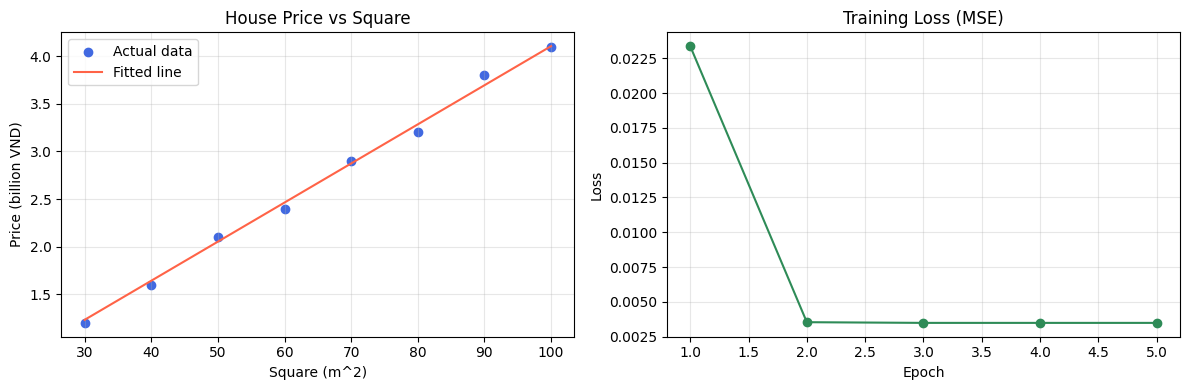

In [10]:
x_line = np.linspace(X.min(), X.max(), 100)
y_line = w * x_line + b

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(X, y, color="royalblue", label="Actual data")
axes[0].plot(x_line, y_line, color="tomato", label="Fitted line")
axes[0].set_title("House Price vs Square")
axes[0].set_xlabel("Square (m^2)")
axes[0].set_ylabel("Price (billion VND)")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, len(loss_history) + 1), loss_history, marker="o", color="seagreen")
axes[1].set_title("Training Loss (MSE)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()